## Seminar 10. Active Learning

In this seminar, we'll train a classification model, gradually adding data annotations using various techniques.

### Agenda

1. Loading data and selecting a model
2. Uncertainty sampling
3. Diversity sampling
4. Price-sensitive sampling

In [275]:
import numpy as np
import matplotlib.pyplot as plt

## Loading Data

We'll use the academic dataset [20 Newsgroups](https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html) as our dataset. This dataset has been used for about 30 years to test models on classification problems. It contains 19,000 posts from 20 newsgroups, divided into 11,500 training texts and 7,500 test texts.

In [15]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset='train')
newsgroups_test = fetch_20newsgroups(subset='test')

In [16]:
len(newsgroups_train.data), len(newsgroups_test.data)

(11314, 7532)

In [279]:
print(newsgroups_train.data[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [18]:
newsgroups_train.target_names, len(newsgroups_train.target_names)

(['alt.atheism',
  'comp.graphics',
  'comp.os.ms-windows.misc',
  'comp.sys.ibm.pc.hardware',
  'comp.sys.mac.hardware',
  'comp.windows.x',
  'misc.forsale',
  'rec.autos',
  'rec.motorcycles',
  'rec.sport.baseball',
  'rec.sport.hockey',
  'sci.crypt',
  'sci.electronics',
  'sci.med',
  'sci.space',
  'soc.religion.christian',
  'talk.politics.guns',
  'talk.politics.mideast',
  'talk.politics.misc',
  'talk.religion.misc'],
 20)

The classes in this dataset are fairly well balanced.

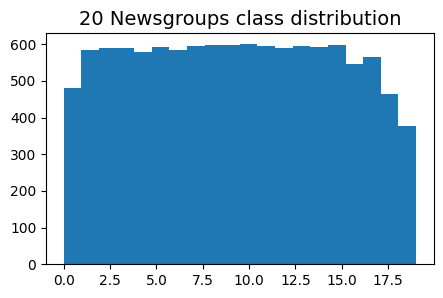

In [283]:
plt.figure(figsize=(5, 3))
plt.hist(newsgroups_train.target, bins=20);
plt.title('20 Newsgroups class distribution', size=14)
plt.show()

The F1 measure is used as standard to assess quality on this dataset.

In [ ]:
from sklearn.metrics import f1_score

## Classification Model

We'll be using a very simple model – Naive Bayes on top of TF-IDF features. We'll need to train it many times, so we don't want to use anything complex. This combination is perfect for demonstrating active learning.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [21]:
tfidf = TfidfVectorizer(min_df=3)

train_tfidf = tfidf.fit_transform(newsgroups_train.data)
test_tfidf = tfidf.transform(newsgroups_test.data)

In [22]:
len(tfidf.vocabulary_)

38869

In [120]:
unlabeled_data = np.array(list(zip(train_tfidf, newsgroups_train.target)))

## Active learning

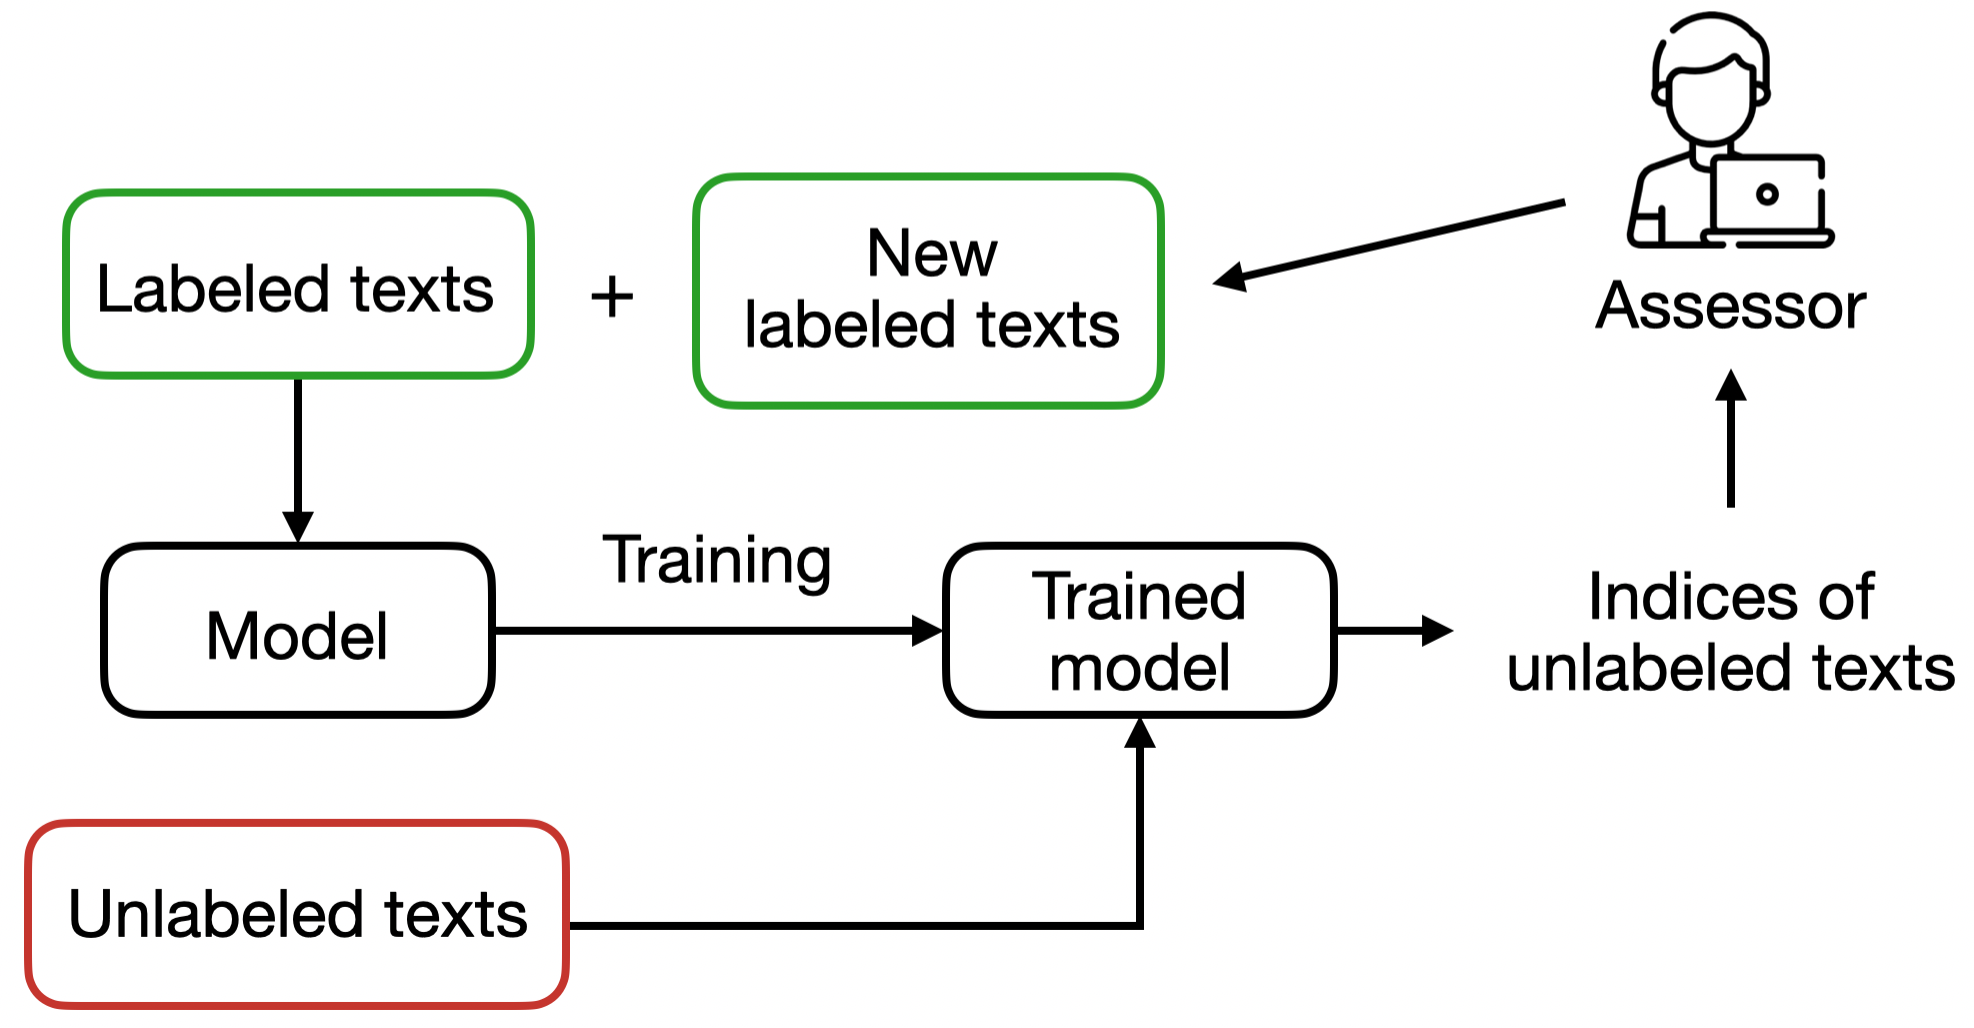


First, let's write the code for the general active learning loop. Then, we'll rewrite the `get_scores` function for each text selection technique for annotation.

In [119]:
from scipy.sparse import vstack


class ActiveLearning:
    def __init__(self, unlabeled_data, min_training_items=512, label_num=128):
        self.unlabeled_data = np.array(unlabeled_data)
        self.labeled_data = []
        
        self.model = MultinomialNB(alpha=0.01)
        self.min_training_items = min_training_items
        self.label_num = label_num

    def init_labeled_data(self):
        """
        Selecting random start texts for labeling
        """
        np.random.seed(0)
        idxs = np.random.choice(
            np.arange(len(self.unlabeled_data)),
            size=self.min_training_items,
            replace=False
        )

        self.labeled_data = self.unlabeled_data[idxs]
        self.unlabeled_data = np.delete(self.unlabeled_data, idxs, 0)
        
    def get_probs(self):
        """
        Returns probability predictions for all unlabeled texts
        """
        x = self.unlabeled_data[:, 0]
        x = vstack(x)
        probs = self.model.predict_proba(x)
        return probs

    def get_scores(self):
        """
        Returns scores for all unlabeled texts.
        Based on these scores, texts are selected for labeling.
        """
        if len(self.unlabeled_data) <= self.label_num:
            return np.zeros(len(self.unlabeled_data))

        return np.random.rand(len(self.unlabeled_data))

    def label_additional_data(self):
        """
        Labels a portion of texts according to their ratings
        """
        if len(self.labeled_data) == 0:
            self.init_labeled_data()
            return
        
        scores = self.get_scores()
        idxs = np.argsort(scores)[-self.label_num:]

        self.labeled_data = np.concatenate((self.labeled_data, self.unlabeled_data[idxs]))
        self.unlabeled_data = np.delete(self.unlabeled_data, idxs, 0)

    def train_model(self):
        """
        Trains the model on all labeled texts
        """
        assert len(self.labeled_data) > 0, "You don't have any labeled data"

        x = self.labeled_data[:, 0]
        x = vstack(x)
        y = self.labeled_data[:, 1].astype(int)
        self.model.fit(x, y)

In [1]:
def run_active_learning(unlabeled_data, al_classes, names):
    """
    Runs active learning for all `al_classes` classes
    and saves F1 score trajectories during the labeling process.
    """
    results = dict()

    for al_class, name in zip(al_classes, names):
        al = al_class(unlabeled_data)

        f1s = []
        while len(al.unlabeled_data) > 0:
            al.label_additional_data()
            al.train_model()

            test_pred = al.model.predict(test_tfidf)
            f1 = f1_score(newsgroups_test.target, test_pred, average='macro')
            f1s.append(f1)

        results[name] = f1s

    return results

In [140]:
def plot_results(results):
    """
    Draws trajectories obtained from `run_active_learning`
    """

    plt.figure(figsize=(5, 3))
    for name, f1s in results.items():
        plt.plot(f1s, label=name)

    plt.xlabel('AL step', size=12)
    plt.ylabel('F1 score', size=12)
    plt.legend()
    plt.grid()
    plt.show()

Let's look at how the quality of the model changes when additionally labeling random texts.

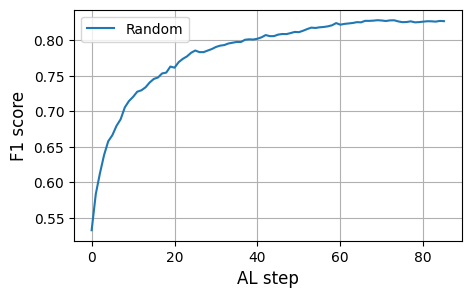

In [159]:
results = run_active_learning(unlabeled_data, [ActiveLearning], names=['Random'])
plot_results(results)

## Uncertainty sampling

Let's start by looking at uncertainty sampling techniques. We'll additionally tag texts that the model is least confident in predicting.

<img src="https://i.ibb.co/YbT2d4w/Group-48099639.png" alt="drawing" width="300"/>

### Least Confident

We label those texts for which the probability of the most probable class is low.

$$score(x) = 1 - \mathbb{P}(\hat{y} | x)$$

<img src="https://i.ibb.co/wMQYg26/least-conf.png" alt="drawing" width="200"/>

In [157]:
class LeastConfidentAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_scores(self):
        probs = self.get_probs()

        least_conf_score = 1 - probs.max(axis=1)
        return least_conf_score

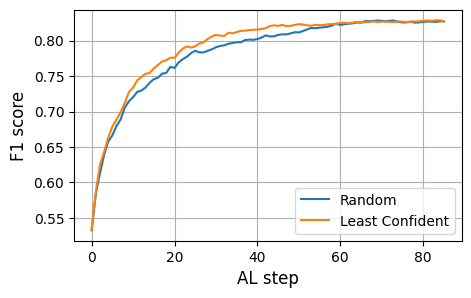

In [160]:
results.update(run_active_learning(unlabeled_data, [LeastConfidentAL], names=['Least Confident']))
plot_results(results)

It's clear that the quality of this approach outperforms random sampling. So active learning works, hooray!

### Margin of Confidence

Least Confident has a significant drawback: it doesn't take into account the probabilities of other classes. Let's try tagging texts for which the difference in probabilities between the most probable classes is minimal.

$$score(x) = 1 - (\mathbb{P}(\hat{y}_1 | x) - \mathbb{P}(\hat{y}_2 | x))$$

<img src="https://i.ibb.co/FKqSqQQ/margin-conf.png" alt="drawing" width="200"/>

In [146]:
class MarginConfidenceAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
    def get_scores(self):
        probs = self.get_probs()

        top_2_probs = np.partition(probs, -2, axis=1)[:, -2:]
        margin_score = 1 - np.abs(top_2_probs[:, 0] - top_2_probs[:, 1])

        return margin_score

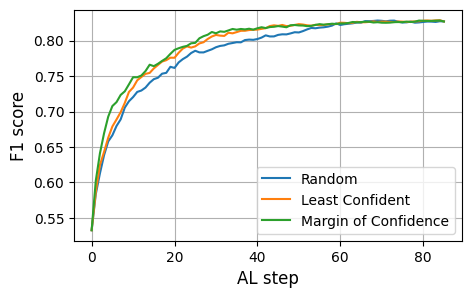

In [161]:
results.update(run_active_learning(unlabeled_data, [MarginConfidenceAL], names=['Margin of Confidence']))
plot_results(results)

In the initial iterations, the quality of this approach turns out to be even higher!

### Ratio of Confidence

Sometimes the ratio of probabilities works better than the difference.

$$score(x) = \frac{\mathbb{P}(\hat{y}_2 | x)}{\mathbb{P}(\hat{y}_1 | x)}$$

In [148]:
class RatioConfidenceAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_scores(self):
        probs = self.get_probs()

        top_2_probs = np.partition(probs, -2, axis=1)[:, -2:]
        ratio_score = np.min(top_2_probs, axis=-1) / np.max(top_2_probs, axis=-1)
        return ratio_score

In [164]:
del results['Least Confident']

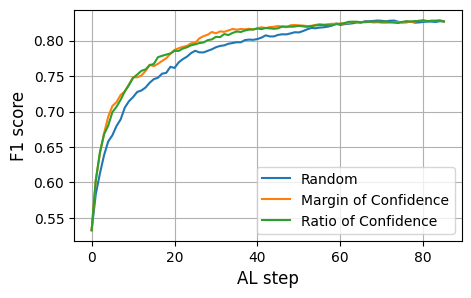

In [163]:
results.update(run_active_learning(unlabeled_data, [RatioConfidenceAL], names=['Ratio of Confidence']))
plot_results(results)

In our case, there is no difference between them.

### Label Entropy

So far, we've only considered the two largest probabilities. We can try considering them all.

$$score(x) = - \sum_{k=1}^K \mathbb{P}(y_k | x) \log \mathbb{P}(y_k | x)$$

In [153]:
class EntropyAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_scores(self):
        probs = self.get_probs()

        entropy = -np.sum(probs * np.log(probs), axis=-1)
        return entropy

In [167]:
del results['Ratio of Confidence']

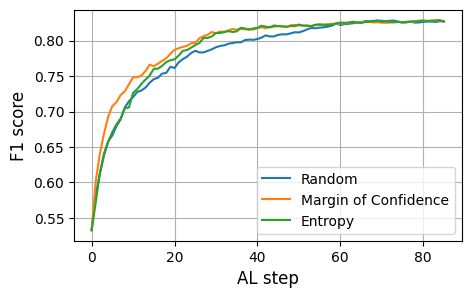

In [168]:
results.update(run_active_learning(unlabeled_data, [EntropyAL], names=['Entropy']))
plot_results(results)

Entropy performs the worst because it samples very similar texts from the center of the distribution.

<img src="https://i.ibb.co/yN2JX7f/Group-48099647.png" alt="drawing" width="800"/>

## Diversity sampling

Let's move on to the second group of methods aimed at labeling a wide variety of texts.

<img src="https://i.ibb.co/fdt3MWf/diversity-sampling.png" alt="drawing" width="300"/>

### Cluster-based

The cluster-based approach labels texts from all clusters uniformly. From each cluster, we select several random texts, a central text, and an outlier.

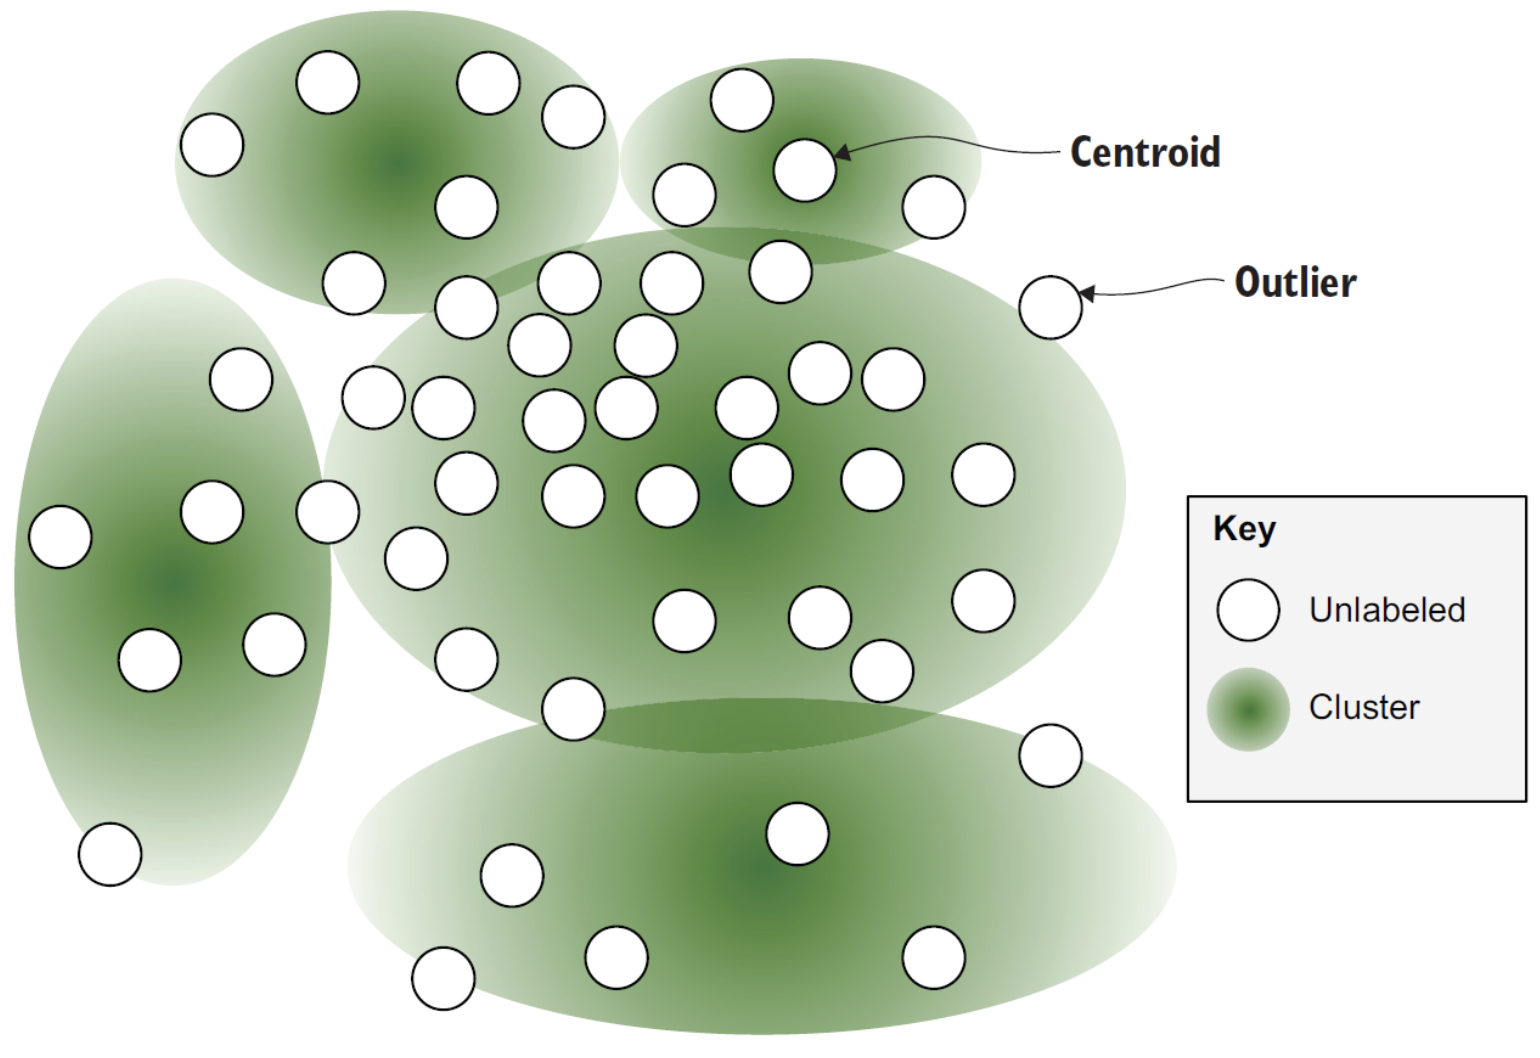

In [173]:
from sklearn.metrics import pairwise_distances_argmin, pairwise_distances
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer


class ClusterBasedAL(ActiveLearning):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.label_num_ = self.label_num

    def get_scores(self):
        self.label_num = self.label_num_

        if len(self.unlabeled_data) <= self.label_num:
            return np.zeros(len(self.unlabeled_data))
        
        x = self.unlabeled_data[:, 0]
        x = vstack(x)

        lsa = make_pipeline(TruncatedSVD(n_components=100), Normalizer(copy=False))
        x_lsa = lsa.fit_transform(x)

        kmeans = KMeans(n_clusters=self.label_num // 5).fit(x_lsa)
        closest_idxs = list(pairwise_distances_argmin(kmeans.cluster_centers_, x_lsa))

        outlier_idxs = []
        for cluster_idx in range(kmeans.n_clusters):
            cluster_x = x_lsa[kmeans.labels_ == cluster_idx]
            centroid = kmeans.cluster_centers_[cluster_idx]
            dists = pairwise_distances([centroid], cluster_x)[0]
            idx = np.argmax(dists[0])
            outlier_idxs.append(np.where(kmeans.labels_ == cluster_idx)[0][idx])

        random_cluster_idxs = []
        for cluster_idx in range(kmeans.n_clusters):
            idxs = np.random.choice(
                np.where(kmeans.labels_ == cluster_idx)[0],
                size=3,
            )
            random_cluster_idxs.extend(idxs)

        idxs = np.unique(closest_idxs + outlier_idxs + random_cluster_idxs)
        self.label_num = len(idxs)

        scores = np.zeros(len(self.unlabeled_data))
        scores[idxs] = 1
        return scores

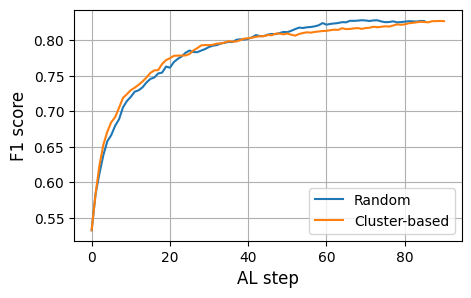

In [174]:
results = run_active_learning(unlabeled_data, [ActiveLearning, ClusterBasedAL], names=['Random', 'Cluster-based'])
plot_results(results)

We see that, compared to random sampling, this technique slightly improved quality initially, but worsened it later. The point is that when there is a large amount of data, it is more important to label the most complex texts rather than the more diverse ones.

## Considering labeling cost

In practice, it's often useful to consider the cost of text labeling when selecting data, as budgets are often limited. It's logical to prioritize cheaper texts.

We'll try two techniques:
1. Rejecting texts if their cost exceeds a certain threshold
2. Return on Investment (ROI)

First, we'll introduce a cost function and rewrite the functions to support cost logging. The cost will be calculated as the number of words in the text.

In [285]:
def get_text_prices(texts):
    return np.array([len(text.split()) for text in texts])

Let's add prices to our data.

In [352]:
prices = get_text_prices(newsgroups_train.data)

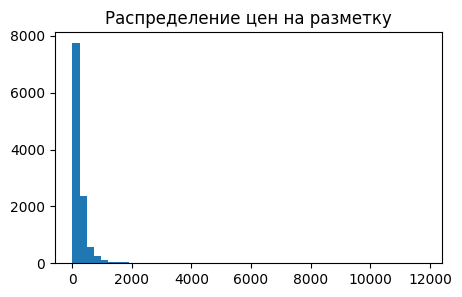

In [344]:
plt.figure(figsize=(5, 3))
plt.title('Распределение цен на разметку')
plt.hist(prices, bins=50);

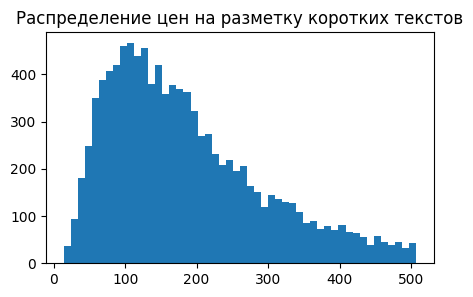

In [353]:
plt.figure(figsize=(5, 3))
long_quantile = np.quantile(prices, 0.9)
plt.title('Распределение цен на разметку коротких текстов')
plt.hist(prices[prices < long_quantile], bins=50);

In [354]:
prices = (prices - prices.min() + 1e-6) / (prices.max() - prices.min())
unlabeled_data = np.array(list(zip(train_tfidf, newsgroups_train.target, prices)))

In [326]:
def run_price_active_learning(unlabeled_data, al_classes, names):
    results = dict()

    for al_class, name in zip(al_classes, names):
        al = al_class(unlabeled_data)

        f1s = []
        prices = []
        while len(al.unlabeled_data) > 0:
            al.label_additional_data()
            al.train_model()

            test_pred = al.model.predict(test_tfidf)
            f1 = f1_score(newsgroups_test.target, test_pred, average='macro')
            f1s.append(f1)

            prices.append(al.labeled_data[:, 2].sum())

        results[name] = {'f1': f1s, 'price': prices}

    return results

In [327]:
def plot_price_results(results):
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    for name, data in results.items():
        plt.plot(data['f1'], label=name)

    plt.xlabel('AL step', size=12)
    plt.ylabel('F1 score', size=12)
    plt.legend()
    plt.grid()
    
    plt.subplot(1, 2, 2)
    for name, data in results.items():
        plt.plot(data['price'], label=name)

    plt.xlabel('AL step', size=12)
    plt.ylabel('Label price', size=12)
    plt.legend()
    plt.grid()
    
    plt.show()

### Not taking expensive texts

We'll impose a price limit on texts and won't label texts longer than approximately 500 words. We'll write a slightly hacky wrapper that takes this criterion into account when selecting texts.

In [358]:
threshold = np.quantile(prices, 0.9)

In [331]:
class MaxPriceActiveLearning:
    def __init__(self, al_class, *args, price_threshold=threshold, **kwargs):
        self.al_class = al_class(*args, **kwargs)
        self.get_orig_scores = self.al_class.get_scores
        self.al_class.get_scores = self.get_scores
        self.price_threshold = price_threshold

        assert self.al_class.unlabeled_data.shape[1] == 3, 'There is no texts in data'

    def get_scores(self):
        scores = self.get_orig_scores()
        prices = self.al_class.unlabeled_data[:, 2]

        scores[prices > self.price_threshold] = -1e+6

        return scores

    def __getattr__(self, name):
        return getattr(self.al_class, name)

In [332]:
from functools import partial

In [333]:
results = run_price_active_learning(
    unlabeled_data,
    [ActiveLearning, partial(MaxPriceActiveLearning, ActiveLearning), partial(MaxPriceActiveLearning, MarginConfidenceAL)],
    names=['Random', 'Price + Random', 'Price + Margin']
)

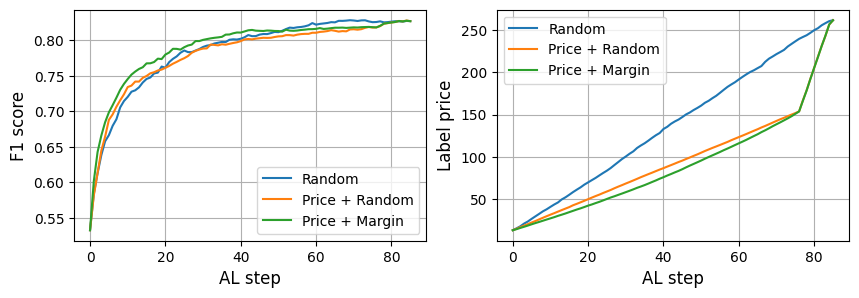

In [334]:
plot_price_results(results)

We managed to maintain almost no loss in quality and save a lot of money on labeling.

## Return on Investment

A smarter technique is to impose a penalty proportional to the cost. For this, you can use Return on Investment, which will show how much we get for each unit of cost.

$$
ROI(x) = \frac{uncertainty(x)}{cost(x)}
$$

It may be useful to scale the cost and uncertainty so that the minimum is 0.

In [339]:
class ROIActiveLearning:
    def __init__(self, al_class, *args, **kwargs):
        self.al_class = al_class(*args, **kwargs)
        self.get_orig_scores = self.al_class.get_scores
        self.al_class.get_scores = self.get_scores

        assert self.al_class.unlabeled_data.shape[1] == 3, 'There is no texts in data'

    def get_scores(self):
        scores = self.get_orig_scores()
        prices = self.al_class.unlabeled_data[:, 2]

        return scores / prices

    def __getattr__(self, name):
        return getattr(self.al_class, name)

In [336]:
results = run_price_active_learning(
    unlabeled_data,
    [ActiveLearning, partial(ROIActiveLearning, ActiveLearning), partial(ROIActiveLearning, MarginConfidenceAL)],
    names=['Random', 'ROI + Random', 'ROI + Margin']
)

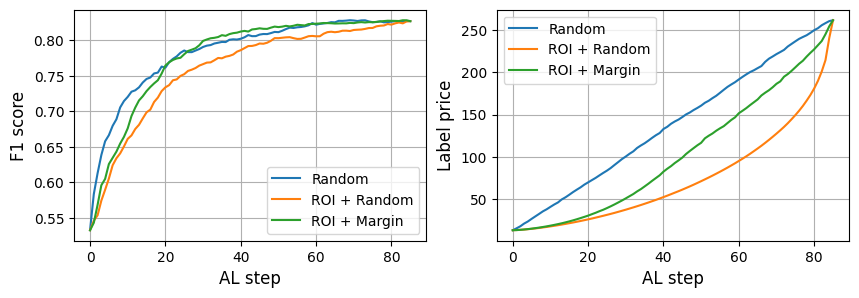

In [322]:
plot_price_results(results)

Let us now compare both approaches.

In [337]:
results = run_price_active_learning(
    unlabeled_data,
    [ActiveLearning, partial(MaxPriceActiveLearning, MarginConfidenceAL), partial(ROIActiveLearning, MarginConfidenceAL)],
    names=['Random', 'Price + Margin', 'ROI + Margin']
)

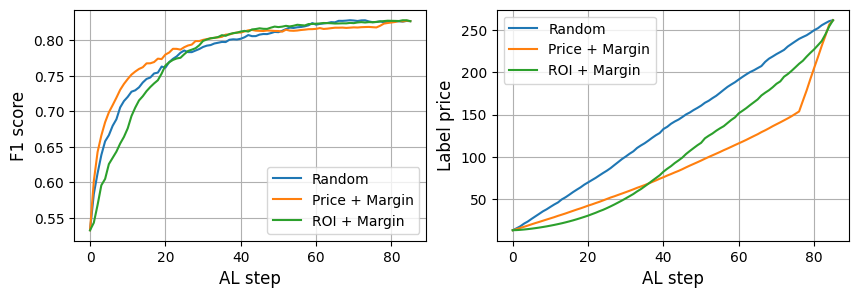

In [338]:
plot_price_results(results)

Suddenly, we find that the simpler method leads to better quality. This is because the cost distribution is very uneven. There's a small set of overly expensive texts, and by not tagging them, we save a ton of money.

### Practical Advices

__Monitoring__

In the real world, there's no way to test different feature selection strategies. You have to modify the strategy during training and carefully monitor the process. Here are a few points to keep in mind when implementing Active Learning:

1. Monitor changes in all model metrics. If the model isn't improving, it's possible that:
    1. You're labeling too little new data compared to the current dataset size.
    1. The data selection strategy is no longer optimal and needs to be changed.
    1. You have a bug in your code that's causing you to label the wrong data.
    1. The dataset is already too large, and no amount of new data will help.

1. The score for labeled data should decrease with each iteration. If not, you're sampling similar examples. If you're using Uncertainty Sampling, the uncertainty may be coming from the data itself, not the model.

__Efficiency__

The cycle of training a model, selecting data for labeling, submitting the selected data, and labeling it can be very time-consuming. This will slow down the training of the entire model. To speed it up, it's important to remember the following:

1. Try to automate everything possible. In Active Learning, manual labeling alone cannot be automated.
1. Not all services allow you to upload additional data for labeling. Make sure your service allows this quickly and that labelers don't have to wait for new data to arrive.
1. The labeling batch size must be large enough to impact the model. If it's too small, you'll simply waste time loading and unloading new data.